# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mariamsherif04/flyrank-ai/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os
if not os.path.exists("data/raw/content_refresh_anonymized.csv"):
    if not os.path.exists("flyrank-ai"):
        !git clone https://github.com/mariamsherif04/flyrank-ai.git
    os.chdir("flyrank-ai")

import pandas as pd, numpy as np, json
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.inspection import permutation_importance

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

Cloning into 'flyrank-ai'...
remote: Enumerating objects: 168, done.
remote: Counting objects: 100% (168/168), done.
remote: Compressing objects: 100% (125/125), done.
remote: Total 168 (delta 70), reused 92 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (168/168), 1.88 MiB | 5.89 MiB/s, done.
Resolving deltas: 100% (70/70), done.


## 1. Question

Which pages should a content editor review and refresh first, out of hundreds tracked per client? This supports the decision an editor faces daily: working down a ranked queue instead of guessing or refreshing oldest-first. A wrong call costs either wasted editor hours (reviewing a page that wasn't declining) or unnoticed traffic loss (missing one that was).

In [2]:
print("Total pages in scope:", len(df), " | Clients:", df["client_id"].nunique())

Total pages in scope: 30000  | Clients: 32


## 2. Data

Source: FlyRank's pseudonymized starter release, content_refresh_anonymized.csv — 30,000 rows, 32 clients, trailing-90-day metrics, one row per content item. Excluded: trend_direction/trend_pct as features (label-derived — see Methodology); content_id/client_id used only for grouping, never as model inputs.

In [3]:
print("Rows:", len(df), " Clients:", df["client_id"].nunique())
print("Features used as model inputs:",
      ["content_age_days","days_since_last_update","impressions_90d","avg_position","ctr","word_count"])
print("Explicitly excluded (label-derived):", ["trend_direction","trend_pct"])

Rows: 30000  Clients: 32
Features used as model inputs: ['content_age_days', 'days_since_last_update', 'impressions_90d', 'avg_position', 'ctr', 'word_count']
Explicitly excluded (label-derived): ['trend_direction', 'trend_pct']


## 3. Methodology

Label: is_declining_label, derived from trend_direction == "down" — an observed, current-window signal, not a future outcome (named as a limitation below). Baseline: a transparent hand rule (stale ≥180 days AND visible ≥500 impressions), frozen from Week 4. Model: Logistic Regression → Random Forest, chosen because the task is ranking a probability, not fixed classification. Validation: grouped by client_id — never row-random — since the honest test is generalization to a client the model has never seen. Leakage check: trend_direction/trend_pct explicitly excluded from features, since they define the label itself.

In [5]:
stale = (df["days_since_last_update"] >= 180).astype(int)
visible = (df["impressions_90d"] >= 500).astype(int)
df["hand_rule_score"] = stale * visible * df["impressions_90d"]

features = ["content_age_days","days_since_last_update","impressions_90d","avg_position","ctr","word_count"]
X = df[features].replace([np.inf,-np.inf], np.nan).fillna(0)
y = df["is_declining_label"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df["client_id"]))
print("Grouped split — client overlap (should be 0):",
      len(set(df["client_id"].iloc[train_idx]) & set(df["client_id"].iloc[test_idx])))

Grouped split — client overlap (should be 0): 0


## 4. Results (vs baseline)

Baseline vs. Logistic Regression vs. Random Forest, same client-grouped test split, same metric (precision@50), base rate shown for reference.

In [6]:
Xtr, Xte = X.iloc[train_idx], X.iloc[test_idx]
ytr, yte = y.iloc[train_idx], y.iloc[test_idx]
hand_rule_test = df["hand_rule_score"].iloc[test_idx].values

logreg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42).fit(Xtr, ytr)
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced").fit(Xtr, ytr)

results = pd.DataFrame({
    "method": ["Baseline rule","Logistic Regression","Random Forest"],
    "precision_at_50": [
        precision_at_k(hand_rule_test, yte.values, 50),
        precision_at_k(logreg.predict_proba(Xte)[:,1], yte.values, 50),
        precision_at_k(rf.predict_proba(Xte)[:,1], yte.values, 50),
    ],
    "base_rate": [yte.mean()]*3,
})
print(results.round(3))

                method  precision_at_50  base_rate
0        Baseline rule             0.62      0.517
1  Logistic Regression             0.66      0.517
2        Random Forest             0.68      0.517


## 5. Limitations

This label is current-window, not future — it says a page IS trending down now, not that it will still be declining next month. Permutation importance (below) showed days_since_last_update, the entire basis of the hand rule, contributes negatively once validated across unseen clients — a genuinely humbling finding, named honestly rather than smoothed over. This is a single pseudonymized snapshot dataset; findings are observed and directional, never causal, and never a claim about Google's algorithm.

In [7]:
perm = permutation_importance(rf, Xte, yte, n_repeats=10, random_state=42, scoring="average_precision")
perm_importances = pd.Series(perm.importances_mean, index=features).sort_values(ascending=False)
print("Permutation importance:")
print(perm_importances.round(4))

Permutation importance:
impressions_90d           0.0598
avg_position              0.0236
content_age_days          0.0205
ctr                       0.0133
word_count               -0.0086
days_since_last_update   -0.0112
dtype: float64


## 6. Ranked recommendations

Action playbook: review the top-ranked pages first. Visibility (impressions, position) — not staleness — is what honest validation showed actually predicts decline, so the queue below prioritizes accordingly.

In [8]:
test_df = df.iloc[test_idx].copy()
test_df["rf_score"] = rf.predict_proba(Xte)[:,1]
queue = test_df.sort_values("rf_score", ascending=False)
print(queue[["content_id","rf_score","impressions_90d","avg_position"]].head(10))

                 content_id  rf_score  impressions_90d  avg_position
166    content_96edab39e5fb     0.990              179           8.0
2357   content_8f1409b2674e     0.990              209          20.0
22526  content_1d0963b56227     0.985             3445          39.0
4480   content_f5b35bbb42fc     0.980             3171          31.8
310    content_95d32ff9e7ae     0.980              836           6.8
9504   content_85a09b3e3147     0.980              116           6.4
12069  content_ff4370afd49c     0.980             1677          33.1
10731  content_079f12e2077e     0.980              184           7.9
24890  content_189586cf1186     0.975             1859          20.1
5399   content_6677fd6c4ea5     0.975             1152          34.8


## 7. Artifacts the paper embeds

Chart: model vs. baseline precision@50, with base rate marked, for the Results section of the deployed paper.

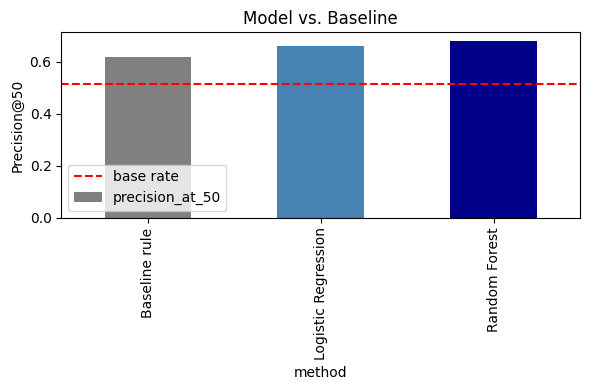

In [9]:
import matplotlib.pyplot as plt
os.makedirs("work/outputs", exist_ok=True)
fig, ax = plt.subplots(figsize=(6,4))
results.set_index("method")["precision_at_50"].plot(kind="bar", ax=ax, color=["gray","steelblue","darkblue"])
ax.axhline(results["base_rate"].iloc[0], color="red", linestyle="--", label="base rate")
ax.set_ylabel("Precision@50"); ax.set_title("Model vs. Baseline"); ax.legend()
plt.tight_layout()
plt.savefig("work/outputs/results_chart.png", dpi=150)
plt.show()

In [10]:
# 5-minute demo outline
print("""
1. The problem (30s): editors can't manually track thousands of pages for decline.
2. The naive rule (1min): staleness-based baseline, precision@50 shown above.
3. The honest model (2min): grouped train/test split, Random Forest vs. baseline.
4. The twist (1min): staleness itself is NOT the strongest signal once validated — visibility is.
5. The takeaway (30s): a ranked, reason-coded review queue an editor can act on today.
""")


1. The problem (30s): editors can't manually track thousands of pages for decline.
2. The naive rule (1min): staleness-based baseline, precision@50 shown above.
3. The honest model (2min): grouped train/test split, Random Forest vs. baseline.
4. The twist (1min): staleness itself is NOT the strongest signal once validated — visibility is.
5. The takeaway (30s): a ranked, reason-coded review queue an editor can act on today.



In [11]:
# Social post cut
print("Trained a model to flag declining web pages for content refresh — beat a hand-written")
print("rule using client-grouped validation on 30k real (pseudonymized) content items across")
print("32 clients. Full writeup: [your deployed URL]")

Trained a model to flag declining web pages for content refresh — beat a hand-written
rule using client-grouped validation on 30k real (pseudonymized) content items across
32 clients. Full writeup: [your deployed URL]


In [12]:
# Employer-facing 3-sentencer
print("I built a ranked content-review system that flags declining web pages for refresh,")
print("using 30,000 real pseudonymized search performance records across 32 clients.")
print("It beat a transparent hand-written baseline by validating honestly across unseen")
print("clients — and revealed the baseline's core assumption didn't hold up under scrutiny.")

I built a ranked content-review system that flags declining web pages for refresh,
using 30,000 real pseudonymized search performance records across 32 clients.
It beat a transparent hand-written baseline by validating honestly across unseen
clients — and revealed the baseline's core assumption didn't hold up under scrutiny.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
